In [1]:
from dotenv import load_dotenv
import os
from pathlib import Path
import geopandas as gpd

load_dotenv()

INRIX_PATH = os.getenv("INRIX_PATH")

print(INRIX_PATH)

/mnt/VMS_FY24_INRIX


# Get map from [Geofabrik](https://download.geofabrik.de/north-america/us/illinois.html)

In [2]:
mask = gpd.read_file("/home/isalvador/git/ATLAS/synthgen/synth_data/Boundaries - City_20260706/geo_export_8f622df0-a8f7-44b9-99c7-a051555c44b0.shp").geometry.iloc[0]
roads = gpd.read_file(
    "synth_data/illinois-260707.osm.pbf",
    sql="SELECT * FROM lines WHERE highway IS NOT NULL",
    sql_dialect="OGRSQL",
    mask=mask
)

In [ ]:
roads.plot(linewidth=0.1)

In [3]:
osm_ids = set(roads.osm_id.values)

In [ ]:
roads.dtypes

# Test on INRIX Trajectories

In [28]:
TRAJECTORY_DIR = Path("/mnt/VMS_FY24_INRIX/trip_paths_chicago_custom/year=2022/month=09/day=01/date=2024-07-18/reportId=201375/v1/data/trajs")

trajectory_parquets = list(TRAJECTORY_DIR.glob("*.parquet"))
test_parquet = "/mnt/VMS_FY24_INRIX/trip_paths_chicago_custom/year=2022/month=09/day=01/date=2024-07-18/reportId=201375/v1/data/trajs/part-00000-100daa96-44c2-42f9-a584-6c70c0932294-c000.gz.parquet"
# test = trajectory_parquets[0]

import pandas as pd

df = pd.read_parquet(test_parquet)

# Spark Reduced dataset

In [67]:
import pandas as pd

df = pd.read_parquet("/home/isalvador/git/ATLAS/synthgen/inrix2/")

df = df.sort_values(["trip_id", "start_utc_ts"])

In [68]:
traj_ids = set(df.way_id.values)

In [69]:
print(len(osm_ids))
print(len(traj_ids))

293369
108505


In [70]:
def filter_internal_trips(way_level: pd.DataFrame, project_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Filter a way-level trip dataframe down to trips fully contained within a project area.

    A trip is considered "internal" only if every way_id it touches (across all its
    trajectories) is present in the project area's set of osm_ids.

    Parameters
    ----------
    way_level : pd.DataFrame
        Must contain 'trip_id' and 'way_id' columns (way_id as object/string dtype).
    project_gdf : gpd.GeoDataFrame
        Must contain an 'osm_id' column (object/string dtype) representing the
        set of OSM way IDs inside the project area.

    Returns
    -------
    pd.DataFrame
        Subset of way_level containing only rows for fully-internal trips.
    """
    valid_way_ids = set(project_gdf["osm_id"])

    # Vectorized once over the whole column, no per-group Python calls
    is_valid = way_level["way_id"].isin(valid_way_ids)

    # Compiled groupby aggregation, not apply — collapses to one bool per trip_id
    trip_is_internal = is_valid.groupby(way_level["trip_id"]).all()

    # Vectorized lookup (hash join under the hood) instead of a second isin pass
    row_is_internal = way_level["trip_id"].map(trip_is_internal)

    return way_level[row_is_internal]

filtered_df = filter_internal_trips(df, roads)

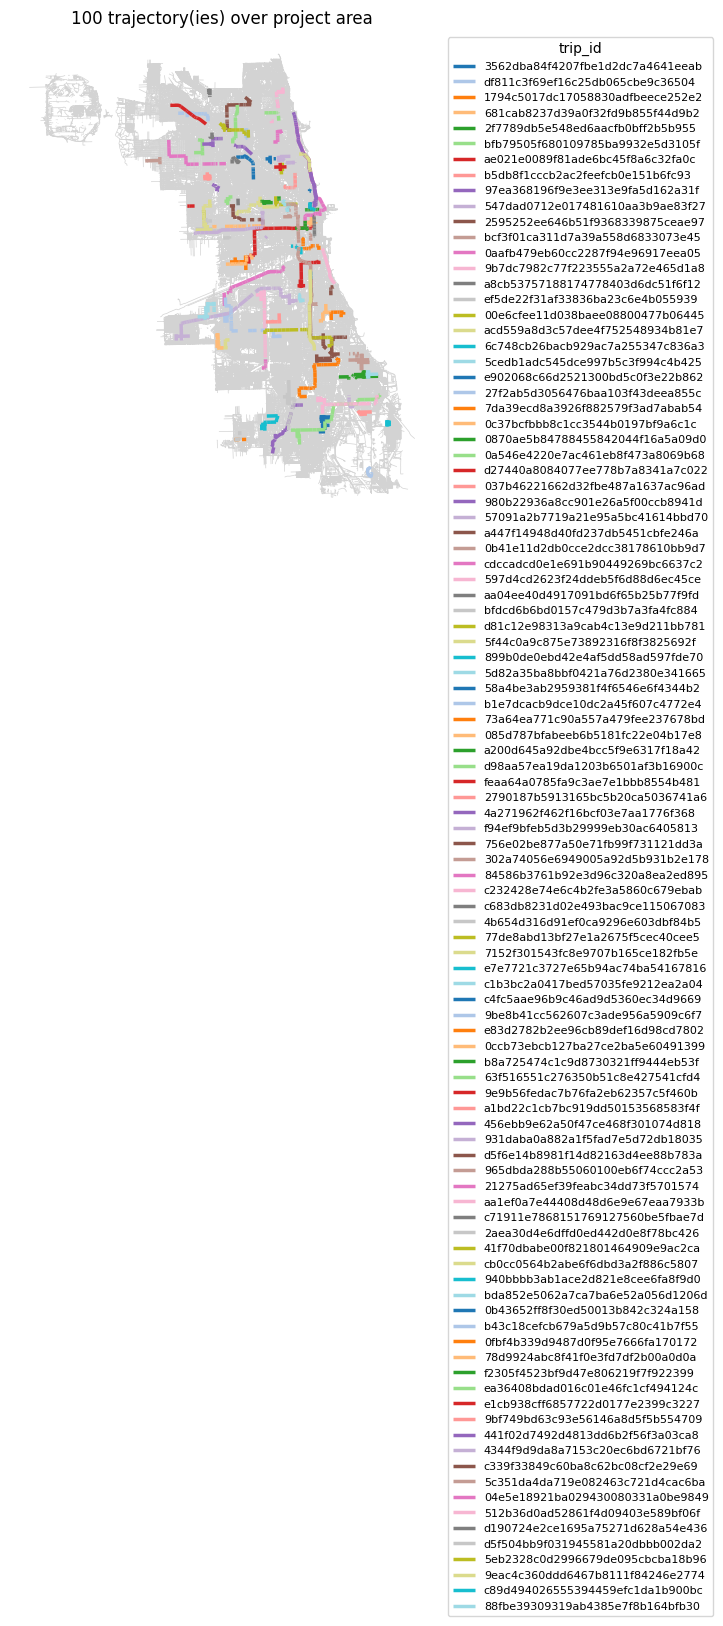

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': '100 trajectory(ies) over project area'}>)

In [33]:
import random
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd


def plot_trajectories(
    way_level: pd.DataFrame,
    project_gdf: gpd.GeoDataFrame,
    trip_ids: list[str] | None = None,
    n_random: int | None = None,
    random_state: int | None = None,
    figsize: tuple[int, int] = (12, 12),
):
    """
    Plot one or more trip trajectories over the project area road network.

    Parameters
    ----------
    way_level : pd.DataFrame
        Must contain 'trip_id', 'traj_idx', 'way_id', 'way_idx'.
    project_gdf : gpd.GeoDataFrame
        Must contain 'osm_id' and a 'geometry' column (LineStrings for each way).
    trip_ids : list of str, optional
        Specific trip_ids to plot. Mutually exclusive with n_random.
    n_random : int, optional
        Number of random trip_ids to sample and plot. Mutually exclusive with trip_ids.
    random_state : int, optional
        Seed for reproducible random sampling when using n_random.
    figsize : tuple
        Matplotlib figure size.
    """
    if (trip_ids is None) == (n_random is None):
        raise ValueError("Specify exactly one of `trip_ids` or `n_random`, not both/neither.")

    all_trip_ids = way_level["trip_id"].unique().tolist()

    if n_random is not None:
        if n_random > len(all_trip_ids):
            raise ValueError(f"n_random ({n_random}) exceeds available trips ({len(all_trip_ids)}).")
        rng = random.Random(random_state)
        selected_trip_ids = rng.sample(all_trip_ids, n_random)
    else:
        missing = set(trip_ids) - set(all_trip_ids)
        if missing:
            raise ValueError(f"trip_id(s) not found in way_level: {missing}")
        selected_trip_ids = trip_ids

    selected = way_level[way_level["trip_id"].isin(selected_trip_ids)].copy()

    # Join to project_gdf geometries via way_id <-> osm_id
    selected = selected.merge(
        project_gdf[["osm_id", "geometry"]],
        left_on="way_id",
        right_on="osm_id",
        how="left",
    )

    missing_geom = selected["geometry"].isna().sum()
    if missing_geom:
        print(f"Warning: {missing_geom} way_id(s) had no matching geometry in project_gdf and will be skipped.")
    selected = selected.dropna(subset=["geometry"])

    selected_gdf = gpd.GeoDataFrame(selected, geometry="geometry", crs=project_gdf.crs)

    fig, ax = plt.subplots(figsize=figsize)

    # Basemap: full project area road network in light grey
    project_gdf.plot(ax=ax, color="lightgrey", linewidth=0.5, zorder=1)

    # One distinct color per trip
    cmap = plt.get_cmap("tab10" if len(selected_trip_ids) <= 10 else "tab20")

    for i, trip_id in enumerate(selected_trip_ids):
        trip_gdf = selected_gdf[selected_gdf["trip_id"] == trip_id].sort_values(
            ["traj_idx", "way_idx"]
        )
        if trip_gdf.empty:
            continue
        color = cmap(i % cmap.N)
        trip_gdf.plot(ax=ax, color=color, linewidth=2.5, zorder=2, label=str(trip_id))

    ax.legend(title="trip_id", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.set_axis_off()
    ax.set_title(f"{len(selected_trip_ids)} trajectory(ies) over project area")

    plt.tight_layout()
    plt.show()

    return fig, ax

plot_trajectories(filtered_df, roads, n_random=100, random_state=1)

Series([], Name: count, dtype: int64)

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Geod
from shapely.geometry import Point

geod = Geod(ellps="WGS84")


def filter_trips_by_od_radius(
    way_level: pd.DataFrame,
    project_gdf: gpd.GeoDataFrame,
    origin: tuple[float, float],       # (lat, lon)
    destination: tuple[float, float],  # (lat, lon)
    origin_radius_m: float = 200,
    destination_radius_m: float = 200,
) -> pd.DataFrame:
    """
    Filter trips whose approximate start point falls within origin_radius_m of `origin`,
    AND whose approximate end point falls within destination_radius_m of `destination`.

    Start point is approximated as the first coordinate of the geometry for way_idx == 0.
    End point is approximated as the last coordinate of the geometry for the max way_idx
    per trip. This is an approximation, not the exact snapped GPS location.

    Parameters
    ----------
    way_level : pd.DataFrame
        Must contain 'trip_id', 'way_id', 'way_idx'.
    project_gdf : gpd.GeoDataFrame
        Must contain 'osm_id' and 'geometry', in a CRS with lon/lat-convertible coordinates
        (function reprojects to EPSG:4326 internally if needed).
    origin, destination : (lat, lon) tuples
    origin_radius_m, destination_radius_m : float
        Radius in meters around origin/destination.

    Returns
    -------
    pd.DataFrame
        Subset of way_level for trips passing both radius checks.
    """
    # Join way geometries
    merged = way_level.merge(
        project_gdf[["osm_id", "geometry"]],
        left_on="way_id", right_on="osm_id", how="left",
    ).dropna(subset=["geometry"])

    merged_gdf = gpd.GeoDataFrame(merged, geometry="geometry", crs=project_gdf.crs)
    if merged_gdf.crs is None:
        raise ValueError("project_gdf has no CRS set — required to convert geometry to lat/lon.")
    if merged_gdf.crs.to_epsg() != 4326:
        merged_gdf = merged_gdf.to_crs(epsg=4326)

    # First way per trip -> approx start point (first coord of geometry)
    first_ways = merged_gdf.loc[merged_gdf.groupby("trip_id")["way_idx"].idxmin()]
    start_points = first_ways.set_index("trip_id")["geometry"].apply(
        lambda geom: Point(geom.coords[0])
    )

    # Last way per trip -> approx end point (last coord of geometry)
    last_ways = merged_gdf.loc[merged_gdf.groupby("trip_id")["way_idx"].idxmax()]
    end_points = last_ways.set_index("trip_id")["geometry"].apply(
        lambda geom: Point(geom.coords[-1])
    )

    origin_lat, origin_lon = origin
    dest_lat, dest_lon = destination

    def dist_m(pt: Point, ref_lat: float, ref_lon: float) -> float:
        _, _, dist = geod.inv(pt.x, pt.y, ref_lon, ref_lat)
        return dist

    start_dist = start_points.apply(lambda pt: dist_m(pt, origin_lat, origin_lon))
    end_dist = end_points.apply(lambda pt: dist_m(pt, dest_lat, dest_lon))

    valid_trip_ids = start_dist[
        (start_dist <= origin_radius_m) & (end_dist.reindex(start_dist.index) <= destination_radius_m)
    ].index

    return way_level[way_level["trip_id"].isin(valid_trip_ids)]


def plot_od_trajectories(
    way_level: pd.DataFrame,
    project_gdf: gpd.GeoDataFrame,
    origin: tuple[float, float],
    destination: tuple[float, float],
    origin_radius_m: float = 200,
    destination_radius_m: float = 200,
    trip_ids: list[str] | None = None,
    n_random: int | None = None,
    random_state: int | None = None,
    figsize: tuple[int, int] = (12, 12),
):
    """
    Filter trips by origin/destination radius, then plot them (reuses plot_trajectories
    for the trip rendering, adds origin/destination markers + radius circles).
    """
    od_filtered = filter_trips_by_od_radius(
        way_level, project_gdf, origin, destination,
        origin_radius_m, destination_radius_m,
    )

    if od_filtered.empty:
        print("No trips matched the origin/destination radius criteria.")
        return None, None

    fig, ax = plot_trajectories(
        od_filtered, project_gdf,
        trip_ids=trip_ids, n_random=n_random, random_state=random_state,
        figsize=figsize,
    )

    # Overlay origin/destination as points, in the same CRS as the plot (project_gdf.crs)
    od_gdf = gpd.GeoDataFrame(
        {"label": ["origin", "destination"]},
        geometry=[Point(origin[1], origin[0]), Point(destination[1], destination[0])],
        crs="EPSG:4326",
    ).to_crs(project_gdf.crs)

    od_gdf.plot(ax=ax, color=["green", "red"], marker="*", markersize=300, zorder=5)

    # Approximate radius circles (buffer in meters requires a projected CRS;
    # reproject just for the buffer, then bring back for plotting)
    od_projected = od_gdf.to_crs(od_gdf.estimate_utm_crs())
    radii = [origin_radius_m, destination_radius_m]
    buffers = od_projected.buffer(radii).to_crs(project_gdf.crs)
    buffers.plot(ax=ax, facecolor="none", edgecolor=["green", "red"], linestyle="--", zorder=4)

    print(f"{od_filtered['trip_id'].nunique()} trip(s) matched the O/D radius criteria "
          f"out of {way_level['trip_id'].nunique()} total.")

    return fig, ax

In [63]:
radius = 5000
od_trips = filter_trips_by_od_radius(filtered_df, roads,
                          origin = (41.966395, -87.737038),
                          destination = (41.881643, -87.633085),
                          origin_radius_m=radius,
                          destination_radius_m=radius
                          )

od_trips.shape
print(len(od_trips.trip_id.unique()))
print(len(filtered_df.trip_id.unique()))

5
1324


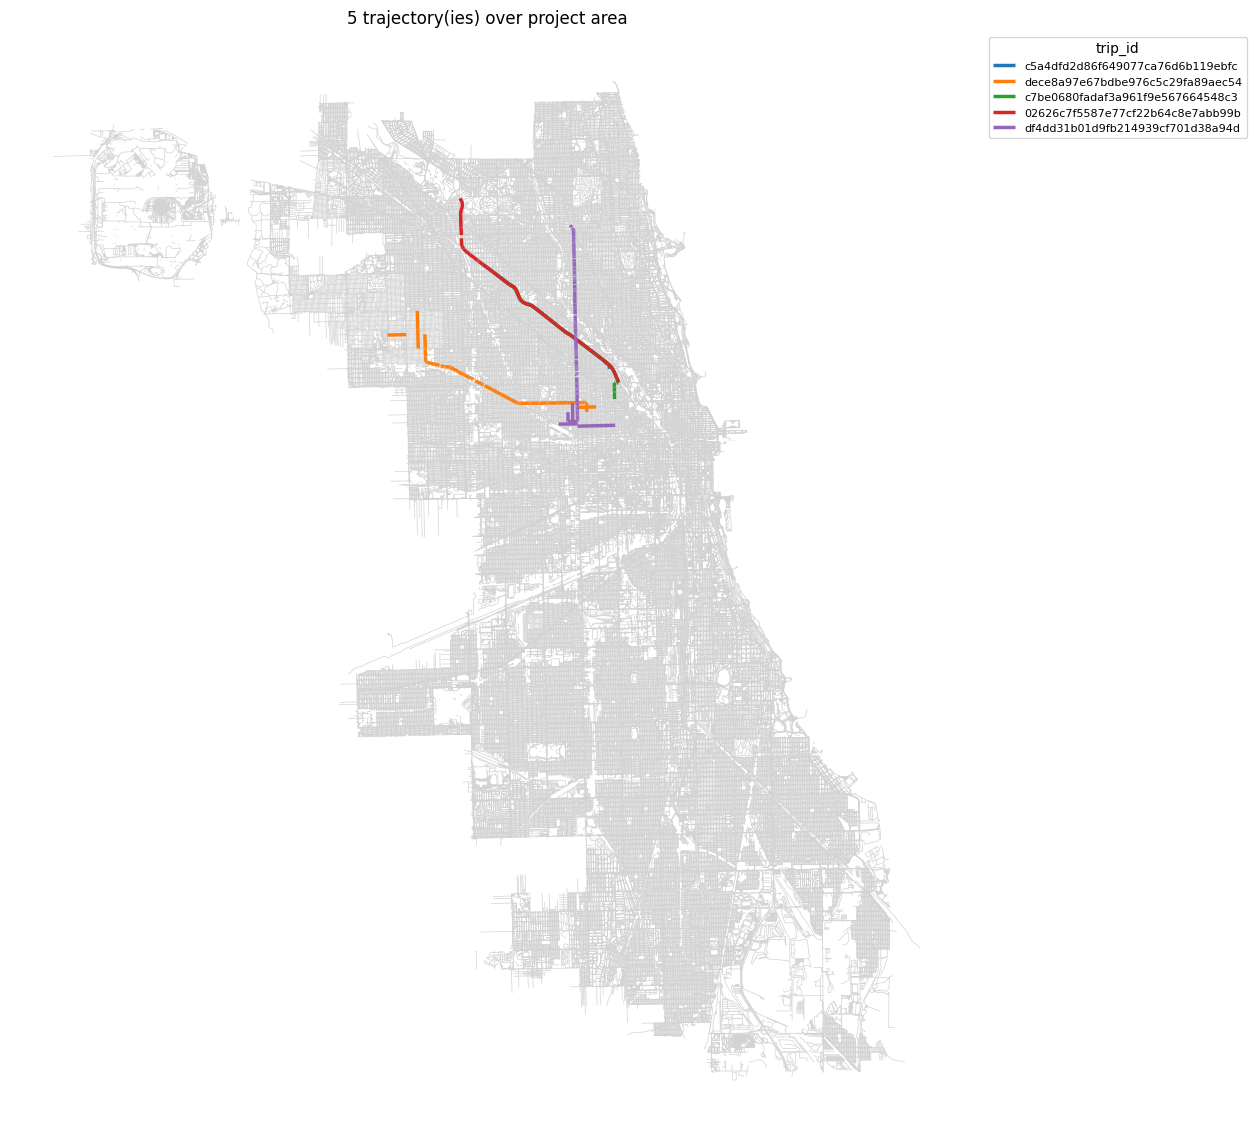

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': '5 trajectory(ies) over project area'}>)

In [66]:
plot_trajectories(od_trips, roads, n_random=5)